# 生成伪实验数据

包含：$I(t)$，$Q(t)$。其中每个样本取200个时间点，训练用50000个样本，测试用10000个样本。

In [38]:
!python src/readout/generate_test_data.py --out data/test_readout.npz --n_train 50000 --n_test 10000

saved: data/test_readout.npz  train=(50000, 200, 2) test=(10000, 200, 2)


# 简单分类

用支持向量机（SVM）对每个样本的平均值：$\langle I(t)\rangle$, $\langle Q(t)\rangle$，直接进行分类。

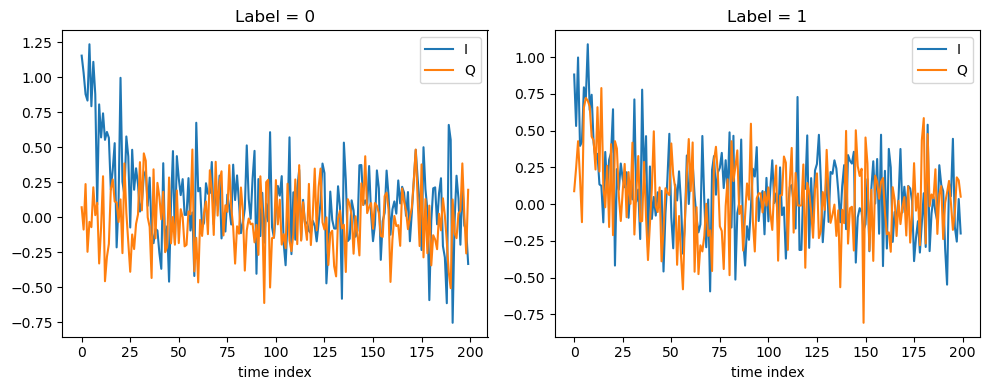

In [39]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_readout.npz", allow_pickle=True)
Xtr, y_train, Xte, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]
X_train = np.mean(Xtr, axis=1)
X_test = np.mean(Xte, axis=1)

rng = np.random.default_rng()
idx0 = rng.choice(np.where(y_train == 0)[0])
idx1 = rng.choice(np.where(y_train == 1)[0])

x0, x1 = Xtr[idx0,:,:], Xtr[idx1,:,:]

t = np.arange(x0.shape[0])

plt.figure(figsize=(10,4))

for (i, x) in zip([0,1], [x0,x1]):
    plt.subplot(1,2,i+1)
    plt.plot(t, x[:,0], label='I')
    plt.plot(t, x[:,1], label='Q')
    plt.title(f"Label = {i}")
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel
Accuracy: 83.12%


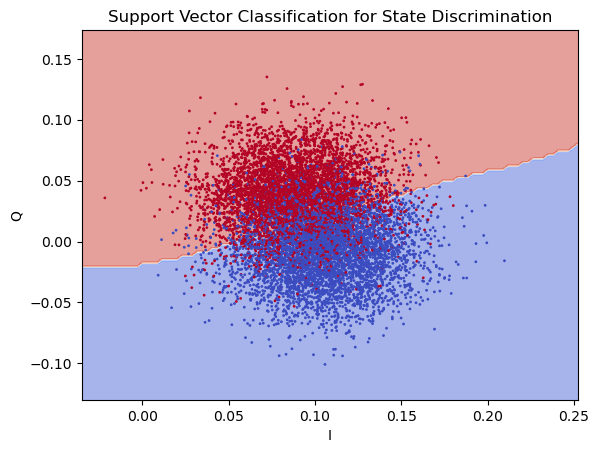

In [40]:
%load_ext cuml.accel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create and train the SVM classifier with RBF kernel
classifier = SVC(kernel='rbf', gamma='scale')
classifier.fit(X_train, y_train)

# # Predict and evaluate
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

# Plot the decision boundary and IQ points
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min() - 0.02, X_train[:, 0].max() + 0.02, 100),
                     np.linspace(X_train[:, 1].min() - 0.02, X_train[:, 1].max() + 0.02, 100))
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=1)
plt.title('Support Vector Classification for State Discrimination')
plt.xlabel('I')
plt.ylabel('Q')
plt.show()


# 用各种机器学习模型分类

优势在于充分利用了 $I(t)$，$Q(t)$ 中的时间信息。

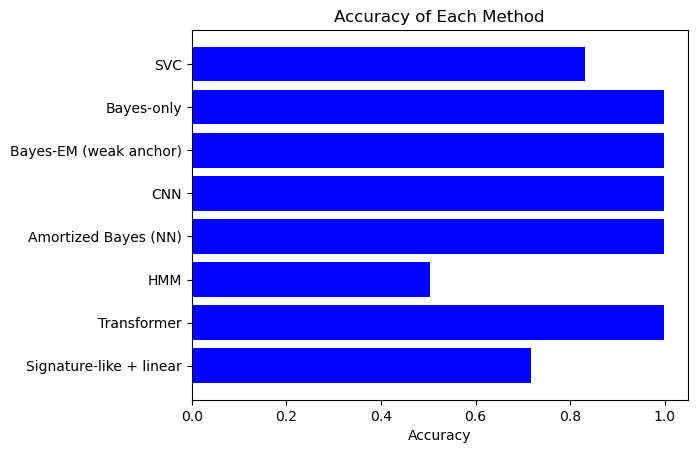

In [43]:
import subprocess
import json
import matplotlib.pyplot as plt

# Run the script and capture output
result = subprocess.run(['python', 'test/test_readout_all.py', '--data', 'data/test_readout.npz', '--hmm_iter', '500'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# Capture the results dictionary from the stdout (if printed by the script)
json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
results = json.loads(json_output)

# Extract accuracies for plotting
methods = ["SVC"] + list(results.keys())
accuracies = [accuracy] + [results[method]["acc"] for method in methods[1:]]

# Plot the accuracies as a bar chart
plt.figure()
plt.barh(methods[::-1], accuracies[::-1], color="b")
plt.xlabel('Accuracy')
plt.title('Accuracy of Each Method')
# plt.grid(True, axis='x')
plt.show()
